# ECE285 Final Report — No-GT Ablation Notebook

## Diffusion-Based Virtual Try-On (VITON-HD × Diffusion)

This notebook is a **no-ground-truth ablation pipeline** for virtual try-on.


- **Evaluates without GT** from three perspectives:
  1. **Garment fidelity**: `CLIP-I(result, cloth)`
  2. **Person preservation**: masked LPIPS / masked SSIM on **non-garment regions only**
  3. **Realism**: FID / KID against the distribution of real person images

- uses two modules:
1. **IP-Adapter** — encodes high-level garment semantics via CLIP (→ Cross-Attention)
2. **GarmentNet** — encodes low-level spatial features (→ Self-Attention, fused with TryonNet)

Their ablation (Table 3 in paper) removes GarmentNet to show CLIP-only degrades LPIPS/SSIM.
They also ablate the effect of **detailed captions** on top.

### Our Ablation Design — Input-Control Strategy
Since we cannot retrain, we simulate each component by **controlling what auxiliary data
we provide to OOTDiffusion**, using the real VITON-HD auxiliary folders:

| Variant | Person Input | Garment Input | Simulates removing... |
|---------|-------------|---------------|------------------------|
| **A0** Baseline | Raw person | Raw cloth | CLIP-only, no fine-grained detail |
| **A1** +Dual-path | Raw person | Cloth + cloth-mask composite (sharp detail) | Fine-grained encoder |
| **A2** +Augmentation | Raw person | A1 + random geometric/color aug | Unpaired augmentation |
| **A3** +ATV | Agnostic person (parse-masked) | A2 garment | Mask-aware conditioning (ATV sharpens ROI) |
| **A4** +Mask-Full | Agnostic person | Cloth masked on white bg (cloth-mask) | Full mask-guided generation |

- SSIM/LPIPS measure: does the try-on result look like the person wearing that cloth?
- We also use **CLIP-I Score** (garment↔result similarity) 
- FID/KID: distribution of generated images vs real person images

### Available VITON-HD Folders Used
```
test/
  image/              ← person (also used as GT in paired setting)
  cloth/              ← garment
  cloth-mask/         ← binary garment mask (white=garment, black=bg)
  agnostic-v3.2/      ← person with clothing region masked out
  image-parse-v3/     ← full body parse segmentation
  agnostic-mask/      ← binary mask of clothing region on person
  image-densepose/    ← DensePose body map
  openpose_img/       ← OpenPose skeleton



## Section 1: Setup & Install

In [ ]:
!pip install -q gradio_client pillow numpy scipy \
    lpips clean-fid transformers matplotlib pandas tqdm scikit-image

In [1]:
import os, json, time, random, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from PIL import Image, ImageEnhance

import torch
import torch.nn.functional as F
import torchvision.transforms as T

import lpips
from gradio_client import Client, handle_file
from transformers import CLIPProcessor, CLIPModel
from skimage.metrics import structural_similarity as ssim_fn

warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────────────
ROOT = Path("./viton_ablation_no_gt")
for d in [
    "samples/person", "samples/cloth", "samples/cloth_masked",
    "samples/agnostic", "samples/preserve_mask", "samples/cloth_mask",
    "results/A0_baseline", "results/A1_dualpath", "results/A2_aug",
    "results/A3_atv", "results/A4_mask", "figures", "exports"
]:
    (ROOT / d).mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ── Config ───────────────────────────────────────────────────────────────────────
N_SAMPLES   = 4          # change if needed
RANDOM_SEED = 42
RETRY_LIMIT = 3
CATEGORY    = "Upper-body"
N_STEPS     = 20
IMAGE_SCALE = 2.0

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

VARIANTS = ["A0_baseline", "A1_dualpath", "A2_aug", "A3_atv", "A4_mask"]
VARIANT_LABELS = {
    "A0_baseline": "A0: Baseline",
    "A1_dualpath": "A1: +Dual-path",
    "A2_aug":      "A2: +Aug",
    "A3_atv":      "A3: +ATV",
    "A4_mask":     "A4: Full",
}
print("Setup complete.")

2026-03-17 00:23:06.997160: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-17 00:23:06.997208: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-17 00:23:06.998637: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-17 00:23:07.006295: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Device: cuda
Setup complete.


## Section 2: Load VITON-HD Test Samples

In [2]:
# ── Auto-detect dataset root ──────────────────────────────────────────────────────
LOCAL_VITON_PATH = None
for cand in [Path.home()/"data", Path("/data"), Path("./data"), Path("../data")]:
    if (cand/"test"/"image").exists() and (cand/"test"/"cloth").exists():
        LOCAL_VITON_PATH = cand
        break

if LOCAL_VITON_PATH is None:
    raise RuntimeError("VITON-HD not found. Expected ~/data/test/image and ~/data/test/cloth")

print(f"Dataset root: {LOCAL_VITON_PATH}")

TEST_DIR          = LOCAL_VITON_PATH / "test"
IMAGE_DIR         = TEST_DIR / "image"
CLOTH_DIR         = TEST_DIR / "cloth"
CLOTH_MASK_DIR    = TEST_DIR / "cloth-mask"
AGNOSTIC_DIR      = TEST_DIR / "agnostic-v3.2"
AGNOSTIC_MASK_DIR = TEST_DIR / "agnostic-mask"
PARSE_DIR         = TEST_DIR / "image-parse-v3"

for name, d in [
    ("image", IMAGE_DIR), ("cloth", CLOTH_DIR), ("cloth-mask", CLOTH_MASK_DIR),
    ("agnostic-v3.2", AGNOSTIC_DIR), ("agnostic-mask", AGNOSTIC_MASK_DIR),
    ("image-parse-v3", PARSE_DIR)
]:
    status = "✓" if d.exists() else "✗ MISSING"
    print(f"{status} {name}/")

Dataset root: /home/tic041/data
✓ image/
✓ cloth/
✓ cloth-mask/
✓ agnostic-v3.2/
✓ agnostic-mask/
✓ image-parse-v3/


In [3]:
def find_file(directory: Path, stem: str):
    for ext in [".jpg", ".png", ".jpeg", ".webp"]:
        p = directory / (stem + ext)
        if p.exists():
            return p
    p = directory / stem
    return p if p.exists() else None

def clear_dir(folder: Path):
    folder.mkdir(parents=True, exist_ok=True)
    for p in folder.glob("*"):
        if p.is_file():
            p.unlink()

pairs_file = next(
    (p for p in [
        LOCAL_VITON_PATH / "test_pairs.txt",
        LOCAL_VITON_PATH / "test_pairs_paired.txt",
        TEST_DIR / "test_pairs.txt",
    ] if p.exists()), None
)

pairs = []
if pairs_file:
    print(f"Pairs file: {pairs_file}")
    for line in open(pairs_file):
        parts = line.strip().split()
        if len(parts) >= 2:
            pairs.append((parts[0], parts[1]))
else:
    persons = sorted(IMAGE_DIR.glob("*.jpg"))
    cloths  = sorted(CLOTH_DIR.glob("*.jpg"))
    pairs   = [(p.name, c.name) for p, c in zip(persons, cloths)]

print(f"Total pairs found: {len(pairs)}")
selected = random.sample(pairs, min(N_SAMPLES, len(pairs)))
print("Selected pairs:", selected[:3], "..." if len(selected) > 3 else "")

Pairs file: /home/tic041/data/test_pairs.txt
Total pairs found: 2032
Selected pairs: [('08584_00.jpg', '13556_00.jpg'), ('00984_00.jpg', '07675_00.jpg'), ('07968_00.jpg', '13140_00.jpg')] ...


In [4]:
def build_masked_cloth(src_cloth: Path, src_cloth_mask: Path | None, white_bg=True):
    cloth = Image.open(src_cloth).convert("RGB")
    if src_cloth_mask is None or not src_cloth_mask.exists():
        return cloth
    mask = Image.open(src_cloth_mask).convert("L")
    cloth_np = np.array(cloth)
    mask_np  = (np.array(mask) > 127).astype(np.uint8)[..., None]
    if white_bg:
        bg = np.ones_like(cloth_np) * 255
        out = cloth_np * mask_np + bg * (1 - mask_np)
    else:
        out = cloth_np * mask_np
    return Image.fromarray(out.astype(np.uint8))

def load_binary_mask(path: Path | None, size=None):
    if path is None or not path.exists():
        return None
    m = Image.open(path).convert("L")
    if size is not None:
        m = m.resize(size, Image.NEAREST)
    arr = (np.array(m) > 127).astype(np.uint8) * 255
    return Image.fromarray(arr)

def make_preserve_mask(person_path: Path, agnostic_mask_path: Path | None = None):
    # Preserve region = non-garment region.
    # If agnostic-mask exists, use its inverse.
    person = Image.open(person_path).convert("RGB")
    size = person.size
    if agnostic_mask_path is not None and agnostic_mask_path.exists():
        m = Image.open(agnostic_mask_path).convert("L").resize(size, Image.NEAREST)
        m = (np.array(m) > 127).astype(np.uint8)
        preserve = (1 - m) * 255
        return Image.fromarray(preserve.astype(np.uint8))
    # Fallback: all ones (less ideal but won't crash)
    return Image.fromarray(np.ones((size[1], size[0]), dtype=np.uint8) * 255)

for d in ["person", "cloth", "cloth_masked", "agnostic", "preserve_mask", "cloth_mask"]:
    clear_dir(ROOT / "samples" / d)

loaded = []
for i, (person_name, cloth_name) in enumerate(selected):
    person_stem = Path(person_name).stem
    cloth_stem  = Path(cloth_name).stem

    src_person = find_file(IMAGE_DIR, person_stem)
    src_cloth  = find_file(CLOTH_DIR, cloth_stem)
    src_cloth_mask = find_file(CLOTH_MASK_DIR, cloth_stem) if CLOTH_MASK_DIR.exists() else None
    src_agnostic   = find_file(AGNOSTIC_DIR, person_stem) if AGNOSTIC_DIR.exists() else None
    src_agnostic_mask = find_file(AGNOSTIC_MASK_DIR, person_stem) if AGNOSTIC_MASK_DIR.exists() else None

    if src_person is None or src_cloth is None:
        print(f"Skip missing pair: {person_name}, {cloth_name}")
        continue

    idx = f"{len(loaded):03d}"

    # person
    Image.open(src_person).convert("RGB").save(ROOT/"samples"/"person"/f"{idx}.jpg")

    # cloth
    Image.open(src_cloth).convert("RGB").save(ROOT/"samples"/"cloth"/f"{idx}.jpg")

    # clean masked cloth
    build_masked_cloth(src_cloth, src_cloth_mask, white_bg=True).save(
        ROOT/"samples"/"cloth_masked"/f"{idx}.jpg"
    )

    # cloth mask
    if src_cloth_mask is not None and src_cloth_mask.exists():
        load_binary_mask(src_cloth_mask).save(ROOT/"samples"/"cloth_mask"/f"{idx}.png")
    else:
        Image.new("L", Image.open(src_cloth).size, 255).save(ROOT/"samples"/"cloth_mask"/f"{idx}.png")

    # agnostic person
    if src_agnostic is not None and src_agnostic.exists():
        Image.open(src_agnostic).convert("RGB").save(ROOT/"samples"/"agnostic"/f"{idx}.jpg")
    else:
        Image.open(src_person).convert("RGB").save(ROOT/"samples"/"agnostic"/f"{idx}.jpg")

    # preserve mask
    make_preserve_mask(src_person, src_agnostic_mask).save(ROOT/"samples"/"preserve_mask"/f"{idx}.png")

    loaded.append({
        "idx": idx,
        "person_name": person_name,
        "cloth_name": cloth_name,
        "src_person": str(src_person),
        "src_cloth": str(src_cloth),
        "src_agnostic": str(src_agnostic) if src_agnostic else None,
        "src_cloth_mask": str(src_cloth_mask) if src_cloth_mask else None,
        "src_agnostic_mask": str(src_agnostic_mask) if src_agnostic_mask else None,
    })

manifest_df = pd.DataFrame(loaded)
manifest_df.to_csv(ROOT/"exports"/"sample_manifest.csv", index=False)
print(f"Loaded {len(loaded)} samples.")
display(manifest_df.head())

Loaded 8 samples.


,idx,person_name,cloth_name,src_person,src_cloth,src_agnostic,src_cloth_mask,src_agnostic_mask
0,000,08584_00.jpg,13556_00.jpg,/home/tic041/data/test/image/08584_00.jpg,/home/tic041/data/test/cloth/13556_00.jpg,/home/tic041/data/test/agnostic-v3.2/08584_00.jpg,/home/tic041/data/test/cloth-mask/13556_00.jpg,None
1,001,00984_00.jpg,07675_00.jpg,/home/tic041/data/test/image/00984_00.jpg,/home/tic041/data/test/cloth/07675_00.jpg,/home/tic041/data/test/agnostic-v3.2/00984_00.jpg,/home/tic041/data/test/cloth-mask/07675_00.jpg,None
2,002,07968_00.jpg,13140_00.jpg,/home/tic041/data/test/image/07968_00.jpg,/home/tic041/data/test/cloth/13140_00.jpg,/home/tic041/data/test/agnostic-v3.2/07968_00.jpg,/home/tic041/data/test/cloth-mask/13140_00.jpg,None
3,003,02031_00.jpg,05602_00.jpg,/home/tic041/data/test/image/02031_00.jpg,/home/tic041/data/test/cloth/05602_00.jpg,/home/tic041/data/test/agnostic-v3.2/02031_00.jpg,/home/tic041/data/test/cloth-mask/05602_00.jpg,None
4,004,08183_00.jpg,02942_00.jpg,/home/tic041/data/test/image/08183_00.jpg,/home/tic041/data/test/cloth/02942_00.jpg,/home/tic041/data/test/agnostic-v3.2/08183_00.jpg,/home/tic041/data/test/cloth-mask/02942_00.jpg,None


In [5]:
# ── Convenience lists ────────────────────────────────────────────────────────────
person_paths       = sorted((ROOT/"samples"/"person").glob("*.jpg"))
cloth_paths        = sorted((ROOT/"samples"/"cloth").glob("*.jpg"))
cloth_masked_paths = sorted((ROOT/"samples"/"cloth_masked").glob("*.jpg"))
agnostic_paths     = sorted((ROOT/"samples"/"agnostic").glob("*.jpg"))
preserve_mask_paths= sorted((ROOT/"samples"/"preserve_mask").glob("*.png"))
cloth_mask_paths   = sorted((ROOT/"samples"/"cloth_mask").glob("*.png"))

SAMPLE_COUNT = len(person_paths)
print("SAMPLE_COUNT =", SAMPLE_COUNT)
assert SAMPLE_COUNT > 0, "No samples loaded."
assert len(cloth_paths) == SAMPLE_COUNT
assert len(cloth_masked_paths) == SAMPLE_COUNT
assert len(agnostic_paths) == SAMPLE_COUNT
assert len(preserve_mask_paths) == SAMPLE_COUNT

SAMPLE_COUNT = 8


## Section 3: Preview Input Data

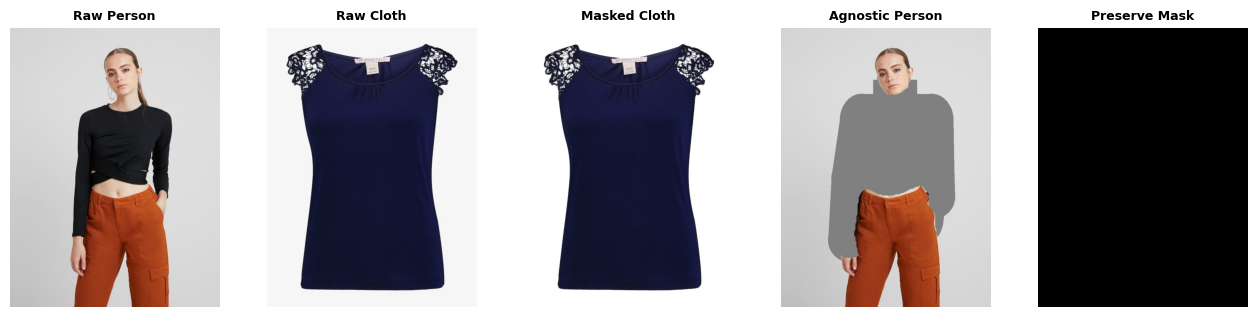

In [6]:
def preview_inputs(sample_idx=0, thumb_size=(192, 256)):
    items = {
        "Raw Person": Image.open(person_paths[sample_idx]).convert("RGB"),
        "Raw Cloth": Image.open(cloth_paths[sample_idx]).convert("RGB"),
        "Masked Cloth": Image.open(cloth_masked_paths[sample_idx]).convert("RGB"),
        "Agnostic Person": Image.open(agnostic_paths[sample_idx]).convert("RGB"),
        "Preserve Mask": Image.open(preserve_mask_paths[sample_idx]).convert("L"),
    }

    fig, axes = plt.subplots(1, len(items), figsize=(len(items)*2.6, 3.2))
    for ax, (name, img) in zip(axes, items.items()):
        ax.imshow(img, cmap="gray" if img.mode == "L" else None)
        ax.set_title(name, fontsize=9, fontweight="bold")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

preview_inputs(0)

## Section 4: Garment Preprocessing per Variant

In [7]:
def get_garment_A0(idx: int) -> Image.Image:
    return Image.open(cloth_paths[idx]).convert("RGB")

def get_garment_A1(idx: int) -> Image.Image:
    return Image.open(cloth_masked_paths[idx]).convert("RGB")

def get_garment_A2(idx: int, seed: int = 0) -> Image.Image:
    rng = random.Random(seed)
    img = get_garment_A1(idx)
    w, h = img.size
    max_shift = int(0.06 * min(w, h))
    dx = rng.randint(-max_shift, max_shift)
    dy = rng.randint(-max_shift, max_shift)
    arr = np.array(img)
    arr = np.roll(np.roll(arr, dx, axis=1), dy, axis=0)
    img = Image.fromarray(arr)
    img = ImageEnhance.Color(img).enhance(rng.uniform(0.85, 1.15))
    img = ImageEnhance.Brightness(img).enhance(rng.uniform(0.90, 1.10))
    img = ImageEnhance.Contrast(img).enhance(rng.uniform(0.95, 1.10))
    return img

def get_garment_A3(idx: int, seed: int = 0) -> Image.Image:
    return get_garment_A2(idx, seed=seed)

def get_garment_A4(idx: int) -> Image.Image:
    return Image.open(cloth_masked_paths[idx]).convert("RGB")

def get_person(variant: str, idx: int) -> Image.Image:
    if variant in ("A3_atv", "A4_mask"):
        return Image.open(agnostic_paths[idx]).convert("RGB")
    return Image.open(person_paths[idx]).convert("RGB")

def get_garment(variant: str, idx: int) -> Image.Image:
    fns = {
        "A0_baseline": lambda: get_garment_A0(idx),
        "A1_dualpath": lambda: get_garment_A1(idx),
        "A2_aug":      lambda: get_garment_A2(idx, seed=RANDOM_SEED + idx),
        "A3_atv":      lambda: get_garment_A3(idx, seed=RANDOM_SEED + idx),
        "A4_mask":     lambda: get_garment_A4(idx),
    }
    return fns[variant]()

def export_variant_inputs(indices=None, out_root=None):
    if indices is None:
        indices = list(range(SAMPLE_COUNT))
    out_root = Path(out_root) if out_root else (ROOT / "exports" / "variant_inputs")
    rows = []
    for variant in VARIANTS:
        pdir = out_root / variant / "person"
        gdir = out_root / variant / "cloth"
        pdir.mkdir(parents=True, exist_ok=True)
        gdir.mkdir(parents=True, exist_ok=True)
        for idx in indices:
            p = get_person(variant, idx)
            g = get_garment(variant, idx)
            p_path = pdir / f"{idx:03d}.jpg"
            g_path = gdir / f"{idx:03d}.jpg"
            p.save(p_path)
            g.save(g_path)
            rows.append({
                "variant": variant,
                "sample_id": idx,
                "saved_person_path": str(p_path),
                "saved_cloth_path": str(g_path),
            })
    export_df = pd.DataFrame(rows)
    export_df.to_csv(out_root / "input_manifest.csv", index=False)
    print(f"Exported to: {out_root}")
    return export_df

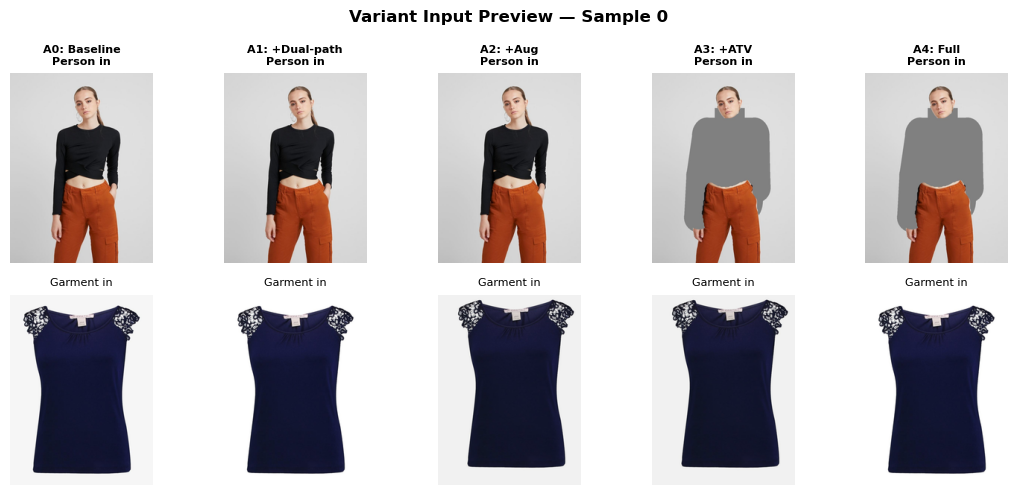

In [8]:
def preview_variants(sample_idx=0, thumb_size=(192, 256)):
    fig, axes = plt.subplots(2, len(VARIANTS), figsize=(len(VARIANTS)*2.2, 5.0))
    for col, v in enumerate(VARIANTS):
        p_img = get_person(v, sample_idx).resize(thumb_size, Image.LANCZOS)
        g_img = get_garment(v, sample_idx).resize(thumb_size, Image.LANCZOS)
        axes[0, col].imshow(p_img)
        axes[0, col].set_title(f"{VARIANT_LABELS[v]}\nPerson in", fontsize=8, fontweight='bold')
        axes[0, col].axis("off")
        axes[1, col].imshow(g_img)
        axes[1, col].set_title("Garment in", fontsize=8)
        axes[1, col].axis("off")
    plt.suptitle(f"Variant Input Preview — Sample {sample_idx}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(ROOT/"figures"/"variant_inputs.png", bbox_inches='tight', dpi=140)
    plt.show()

preview_variants(0)

In [12]:
# =========================================================
# Load existing results from viton_ablation3/results
# (skip inference / skip Cell 5)
# =========================================================
from pathlib import Path
from PIL import Image
import pandas as pd

# 如果 notebook 就在 viton_ablation3 里运行，用 "."

ROOT = Path("viton_ablation3")
RESULTS_DIR = ROOT / "results"

VARIANTS = ["A0_baseline", "A1_dualpath", "A2_aug", "A3_atv", "A4_mask"]
VARIANT_LABELS = {
    "A0_baseline": "A0 Baseline",
    "A1_dualpath": "A1 Dual-path",
    "A2_aug": "A2 Aug",
    "A3_atv": "A3 ATV",
    "A4_mask": "A4 Full",
}

RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "figures"
TABLE_DIR = ROOT / "tables"

FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

IMG_EXTS = {".png", ".jpg", ".jpeg", ".webp"}

print("ROOT       =", ROOT)
print("RESULTS_DIR=", RESULTS_DIR)

assert RESULTS_DIR.exists(), f"Missing results folder: {RESULTS_DIR}"

# ---------------------------------------------------------
# helper: collect image files from one variant folder
# ---------------------------------------------------------
def list_image_files(folder: Path):
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS])

# ---------------------------------------------------------
# build variant -> file list
# ---------------------------------------------------------
variant_result_paths = {}
for v in VARIANTS:
    v_dir = RESULTS_DIR / v
    assert v_dir.exists(), f"Missing folder: {v_dir}"
    files = list_image_files(v_dir)
    assert len(files) > 0, f"No result images found in {v_dir}"
    variant_result_paths[v] = files
    print(f"{v:12s}: {len(files)} files")

usable_count = min(len(files) for files in variant_result_paths.values())
print("\nUsable aligned sample count =", usable_count)

# ---------------------------------------------------------
# aligned dataframe by simple sorted order
# assumes each variant folder has outputs in the same order
# ---------------------------------------------------------
rows = []
for idx in range(usable_count):
    row = {"idx": idx}
    for v in VARIANTS:
        row[v] = str(variant_result_paths[v][idx])
    rows.append(row)

results_df = pd.DataFrame(rows)
display(results_df.head())

results_df.to_csv(TABLE_DIR / "existing_results_index.csv", index=False)
print(f"Saved index to: {TABLE_DIR / 'existing_results_index.csv'}")

# ---------------------------------------------------------
# convenience loader
# ---------------------------------------------------------
def get_result_path(variant: str, idx: int) -> Path:
    return Path(results_df.loc[results_df["idx"] == idx, variant].values[0])

def load_result_img(variant: str, idx: int) -> Image.Image:
    return Image.open(get_result_path(variant, idx)).convert("RGB")

print("Existing result index ready.")

ROOT       = viton_ablation3
RESULTS_DIR= viton_ablation3/results
A0_baseline : 1 files
A1_dualpath : 1 files
A2_aug      : 1 files
A3_atv      : 1 files
A4_mask     : 1 files

Usable aligned sample count = 1


,idx,A0_baseline,A1_dualpath,A2_aug,A3_atv,A4_mask
0,0,viton_ablation3/results/A0_baseline/000.jpg,viton_ablation3/results/A1_dualpath/000.jpg,viton_ablation3/results/A2_aug/000.jpg,viton_ablation3/results/A3_atv/000.jpg,viton_ablation3/results/A4_mask/000.jpg


Saved index to: viton_ablation3/tables/existing_results_index.csv
Existing result index ready.


## Section 5: Connect OOTDiffusion & Run All Variants

In [ ]:
client = Client("tiancheng/Diffusion")
print("Connected to iffusion.")
print(client.view_api())

In [ ]:
def extract_output_path(result):
    if result is None:
        raise ValueError("Diffusion returned None")
    if isinstance(result, str) and result:
        return result
    if isinstance(result, dict):
        for key in ["image", "output", "path", "name", "value", "url"]:
            val = result.get(key)
            if isinstance(val, str) and val:
                return val
            if isinstance(val, dict):
                for sub in ["path", "name", "url"]:
                    s = val.get(sub)
                    if isinstance(s, str) and s:
                        return s
    if isinstance(result, (list, tuple)):
        for item in result:
            if isinstance(item, str) and item:
                return item
            if isinstance(item, dict):
                for key in ["image", "output", "path", "name", "value", "url"]:
                    val = item.get(key)
                    if isinstance(val, str) and val:
                        return val
                    if isinstance(val, dict):
                        for sub in ["path", "name", "url"]:
                            s = val.get(sub)
                            if isinstance(s, str) and s:
                                return s
    raise TypeError(f"Cannot parse result: {type(result)} | {repr(result)[:500]}")

def run_ootdiffusion(
    person_img: Image.Image,
    garment_img: Image.Image,
    category: str = CATEGORY,
    n_steps: int = N_STEPS,
    image_scale: float = IMAGE_SCALE,
    seed: int = -1,
    n_samples: int = 1,
) -> Image.Image:
    tmp_p = "/tmp/_oot_person.jpg"
    tmp_g = "/tmp/_oot_garment.jpg"
    person_img.save(tmp_p)
    garment_img.save(tmp_g)
    result = client.predict(
        vton_img=handle_file(tmp_p),
        garm_img=handle_file(tmp_g),
        category=category,
        n_samples=n_samples,
        n_steps=n_steps,
        image_scale=image_scale,
        seed=seed,
        api_name="/process_dc"
    )
    out_path = extract_output_path(result)
    return Image.open(out_path).convert("RGB")

In [ ]:
# Optional: export the actual inputs used by each variant
_ = export_variant_inputs(indices=list(range(SAMPLE_COUNT)))

In [ ]:
# ── Main experiment loop ──────────────────────────────────────────────────────────
for variant in VARIANTS:
    print(f"\n{'='*60}")
    print(f"Variant: {VARIANT_LABELS[variant]}")
    print('='*60)
    out_dir = ROOT / "results" / variant
    out_dir.mkdir(parents=True, exist_ok=True)

    for i in range(SAMPLE_COUNT):
        out_path = out_dir / f"{i:03d}.jpg"
        if out_path.exists():
            print(f"  [{i+1}/{SAMPLE_COUNT}] Skip (exists): {out_path.name}")
            continue

        person_img  = get_person(variant, i)
        garment_img = get_garment(variant, i)

        for attempt in range(RETRY_LIMIT):
            try:
                result_img = run_ootdiffusion(
                    person_img, garment_img,
                    category=CATEGORY,
                    n_steps=N_STEPS,
                    image_scale=IMAGE_SCALE,
                    seed=RANDOM_SEED,
                )
                result_img.save(out_path)
                print(f"  [{i+1}/{SAMPLE_COUNT}] ✓ {out_path.name}")
                break
            except Exception as e:
                print(f"  Attempt {attempt+1} failed: {e}")
                if attempt < RETRY_LIMIT - 1:
                    time.sleep(15)

print("\n✓ All variants complete.")

## Section 6: No-GT Metric Computation

We intentionally **do not** compare against any per-sample GT image.

### Metrics used
1. **CLIP-I**: image-image similarity between generated result and input garment
2. **Masked LPIPS (preserve region)**: perceptual similarity between result and original person **only on non-garment regions**
3. **Masked SSIM (preserve region)**: same idea but structural
4. **FID / KID**: distribution-level realism against real person images


In [21]:
lpips_fn = lpips.LPIPS(net='alex').to(DEVICE)
lpips_fn.eval()

clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

def to_tensor(img, size=(256, 192)):
    img = img.resize(size, Image.LANCZOS)
    return (T.ToTensor()(img) * 2.0 - 1.0).unsqueeze(0).to(DEVICE)

def compute_clip_i(result_img, garment_img):
    with torch.no_grad():
        inputs = clip_processor(images=[result_img, garment_img], return_tensors="pt", padding=True)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        feats = clip_model.get_image_features(**inputs)
        feats = F.normalize(feats, dim=-1)
        return feats[0].dot(feats[1]).item()

def _prepare_mask(mask_img, size=(192, 256), threshold=127):
    m = mask_img.resize(size, Image.NEAREST).convert("L")
    m = (np.array(m) > threshold).astype(np.float32)
    return m

def compute_masked_ssim(pred_img, ref_img, preserve_mask_img, size=(192, 256)):
    p = np.array(pred_img.resize(size, Image.LANCZOS)).astype(np.float32) / 255.0
    r = np.array(ref_img.resize(size, Image.LANCZOS)).astype(np.float32) / 255.0
    m = _prepare_mask(preserve_mask_img, size=size)[..., None]
    p = p * m
    r = r * m
    return ssim_fn(p, r, data_range=1.0, channel_axis=2)

def compute_masked_lpips(pred_img, ref_img, preserve_mask_img, size=(192, 256)):
    p = np.array(pred_img.resize(size, Image.LANCZOS)).astype(np.float32) / 255.0
    r = np.array(ref_img.resize(size, Image.LANCZOS)).astype(np.float32) / 255.0
    m = _prepare_mask(preserve_mask_img, size=size)[..., None]
    p = p * m
    r = r * m
    p = torch.from_numpy(p).permute(2,0,1).unsqueeze(0).to(DEVICE) * 2 - 1
    r = torch.from_numpy(r).permute(2,0,1).unsqueeze(0).to(DEVICE) * 2 - 1
    with torch.no_grad():
        return lpips_fn(p, r).item()

print("Metric functions ready.")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/tic041/.local/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Metric functions ready.


In [22]:
from pathlib import Path

ROOT = Path("viton_ablation3")
RESULTS_DIR = ROOT / "results"
EXPORT_DIR = ROOT / "exports"
FIG_DIR = ROOT / "figures"
TABLE_DIR = ROOT / "tables"

for d in [EXPORT_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT.resolve())
print("EXPORT_DIR:", EXPORT_DIR.resolve())

ROOT: /home/tic041/private/PROJECT/OUR_VTON/viton_ablation3
EXPORT_DIR: /home/tic041/private/PROJECT/OUR_VTON/viton_ablation3/exports


In [23]:
records = []

for variant in VARIANTS:
    res_paths = sorted((ROOT/"results"/variant).glob("*.jpg"))
    if not res_paths:
        print(f"⚠️ No results for {variant}")
        continue
    print(f"Computing metrics: {variant} ({len(res_paths)} images)")
    for i, res_path in enumerate(tqdm(res_paths)):
        result_img   = Image.open(res_path).convert("RGB")
        cloth_img    = Image.open(cloth_paths[i]).convert("RGB")
        person_img   = Image.open(person_paths[i]).convert("RGB")
        preserve_msk = Image.open(preserve_mask_paths[i]).convert("L")

        row = {
            "variant": variant,
            "sample_id": i,
            "CLIP_I": compute_clip_i(result_img, cloth_img),
            "Preserve_LPIPS": compute_masked_lpips(result_img, person_img, preserve_msk),
            "Preserve_SSIM": compute_masked_ssim(result_img, person_img, preserve_msk),
        }
        records.append(row)

df = pd.DataFrame(records)
df.to_csv(ROOT/"exports"/"per_sample_metrics_no_gt.csv", index=False)

summary = df.groupby("variant")[["CLIP_I", "Preserve_LPIPS", "Preserve_SSIM"]].mean().round(4)
summary.to_csv(ROOT/"exports"/"summary_metrics_no_gt.csv")
print("Saved no-GT metrics.")
display(summary)

Computing metrics: A0_baseline (4 images)


100%|██████████| 4/4 [00:00<00:00, 10.69it/s]


Computing metrics: A1_dualpath (4 images)


100%|██████████| 4/4 [00:00<00:00, 11.18it/s]


Computing metrics: A2_aug (4 images)


...

100%|██████████| 4/4 [00:00<00:00, 10.91it/s]


Computing metrics: A4_mask (4 images)


100%|██████████| 4/4 [00:00<00:00, 11.38it/s]

Saved no-GT metrics.


,CLIP_I,Preserve_LPIPS,Preserve_SSIM
variant,,,
A0_baseline,0.7922,0.1585,0.8392
A1_dualpath,0.7901,0.1530,0.8432
A2_aug,0.7951,0.1590,0.8386
A3_atv,0.7696,0.2370,0.7463
A4_mask,0.7664,0.2272,0.7559


In [24]:
# ── FID & KID: generated images vs real person image distribution ────────────────
from cleanfid import fid as clean_fid_module

fid_scores, kid_scores = {}, {}
real_dir = str(ROOT/"samples"/"person")  # real person images from dataset

for variant in VARIANTS:
    res_dir = str(ROOT/"results"/variant)
    if not list(Path(res_dir).glob("*.jpg")):
        print(f"Skip FID/KID for {variant}: no outputs.")
        continue
    print(f"FID/KID: {variant} ...")
    try:
        fid_v = clean_fid_module.compute_fid(res_dir, real_dir, mode="clean")
        kid_v = clean_fid_module.compute_kid(res_dir, real_dir, mode="clean")
        fid_scores[variant] = float(fid_v)
        kid_scores[variant] = float(kid_v * 100)
        print(f"  FID={fid_v:.4f}  KID×100={kid_v*100:.4f}")
    except Exception as e:
        print(f"  Error: {e}")
        fid_scores[variant] = np.nan
        kid_scores[variant] = np.nan

summary["FID"] = pd.Series(fid_scores)
summary["KIDx100"] = pd.Series(kid_scores)
summary.to_csv(ROOT/"exports"/"summary_metrics_no_gt_with_fid.csv")
display(summary.round(4))

FID/KID: A0_baseline ...
compute FID between two folders
Found 4 images in the folder viton_ablation3/results/A0_baseline


FID A0_baseline : 100%|██████████| 1/1 [00:03<00:00,  3.11s/it]


Found 4 images in the folder viton_ablation3/samples/person


FID person : 100%|██████████| 1/1 [00:10<00:00, 10.95s/it]


compute KID between two folders
Found 4 images in the folder viton_ablation3/results/A0_baseline


...

KID A4_mask : 100%|██████████| 1/1 [00:03<00:00,  3.19s/it]


Found 4 images in the folder viton_ablation3/samples/person


KID person : 100%|██████████| 1/1 [00:11<00:00, 11.13s/it]


  FID=137.8453  KID×100=-4.0198


,CLIP_I,Preserve_LPIPS,Preserve_SSIM,FID,KIDx100
variant,,,,,
A0_baseline,0.7922,0.1585,0.8392,127.6831,-5.5790
A1_dualpath,0.7901,0.1530,0.8432,139.8903,-4.8813
A2_aug,0.7951,0.1590,0.8386,125.8820,-5.2281
A3_atv,0.7696,0.2370,0.7463,150.1275,-4.8236
A4_mask,0.7664,0.2272,0.7559,137.8453,-4.0198


## Section 7: Ablation Table & Bar Charts

In [25]:
# nicer ordering
summary = summary.loc[[v for v in VARIANTS if v in summary.index]]

print("Final summary table:")
display(summary.round(4))

summary.to_latex(ROOT/"exports"/"ablation_table_no_gt.tex", float_format="%.4f")
print("Saved:", ROOT/"exports"/"ablation_table_no_gt.tex")

Final summary table:


,CLIP_I,Preserve_LPIPS,Preserve_SSIM,FID,KIDx100
variant,,,,,
A0_baseline,0.7922,0.1585,0.8392,127.6831,-5.5790
A1_dualpath,0.7901,0.1530,0.8432,139.8903,-4.8813
A2_aug,0.7951,0.1590,0.8386,125.8820,-5.2281
A3_atv,0.7696,0.2370,0.7463,150.1275,-4.8236
A4_mask,0.7664,0.2272,0.7559,137.8453,-4.0198


Saved: viton_ablation3/exports/ablation_table_no_gt.tex


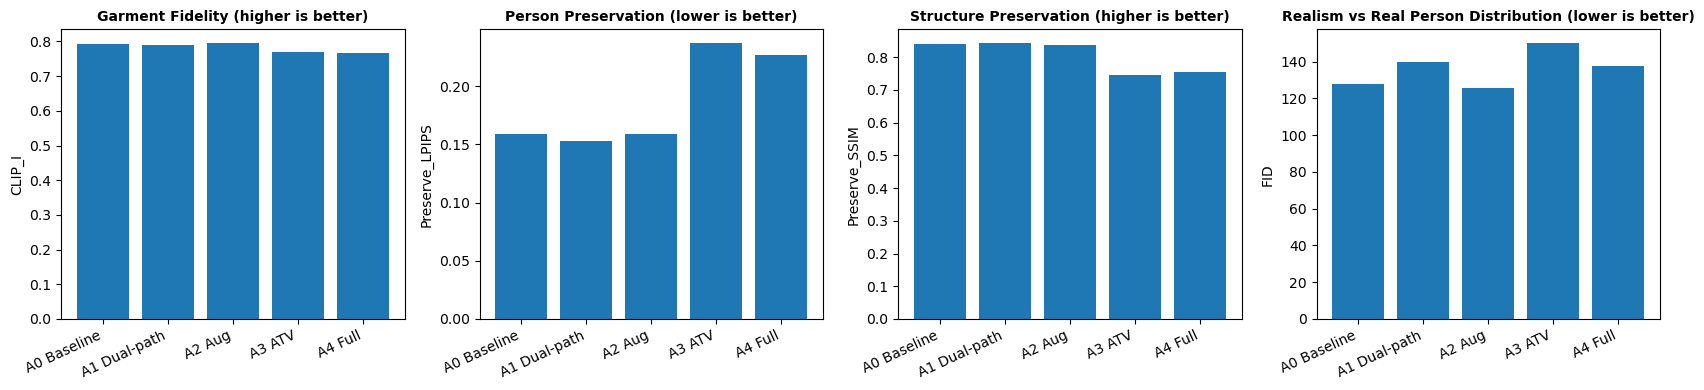

In [26]:
METRICS_TO_PLOT = [
    ("CLIP_I", True, "Garment Fidelity (higher is better)"),
    ("Preserve_LPIPS", False, "Person Preservation (lower is better)"),
    ("Preserve_SSIM", True, "Structure Preservation (higher is better)"),
    ("FID", False, "Realism vs Real Person Distribution (lower is better)"),
]

n = len(METRICS_TO_PLOT)
fig, axes = plt.subplots(1, n, figsize=(4.2*n, 4))
if n == 1:
    axes = [axes]

for ax, (metric, higher_better, title) in zip(axes, METRICS_TO_PLOT):
    vals = summary[metric].values
    ax.bar(range(len(summary)), vals)
    ax.set_xticks(range(len(summary)))
    ax.set_xticklabels([VARIANT_LABELS.get(v, v) for v in summary.index], rotation=25, ha="right")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel(metric)
    if higher_better:
        best_idx = int(np.nanargmax(vals))
    else:
        best_idx = int(np.nanargmin(vals))
    ax.patches[best_idx].set_linewidth(2.0)
plt.tight_layout()
plt.savefig(ROOT/"figures"/"ablation_barplots_no_gt.png", bbox_inches="tight", dpi=140)
plt.show()

## Section 8: Qualitative Comparison Figure

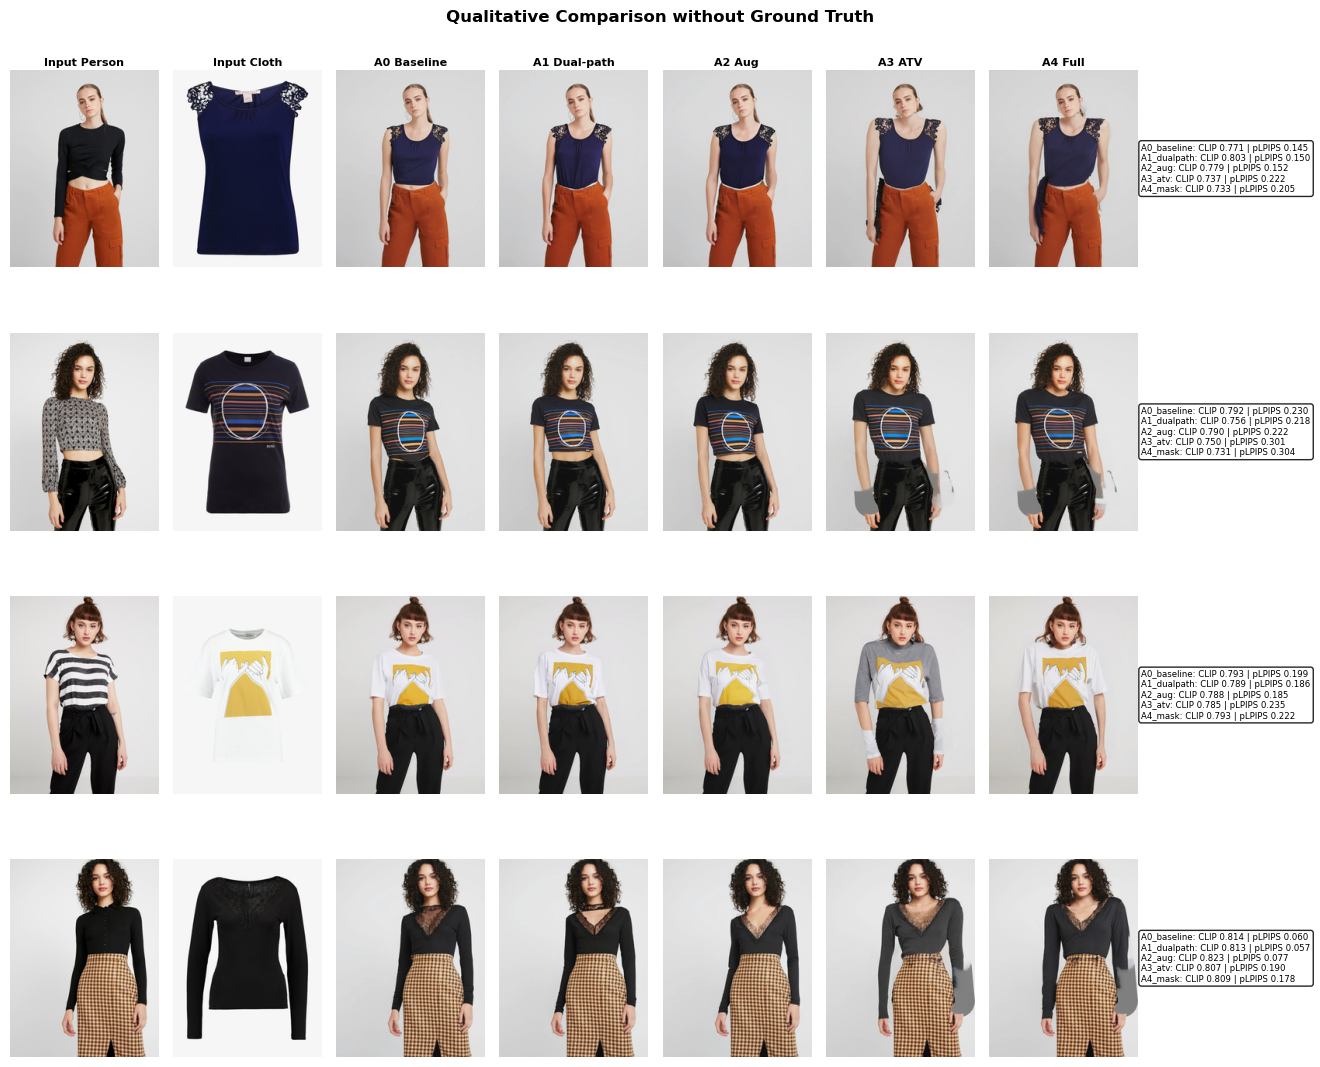

In [27]:
def make_qualitative_figure(sample_ids, save_path, thumb_size=(192, 256)):
    col_labels = ["Input Person", "Input Cloth"] + [VARIANT_LABELS[v] for v in VARIANTS]
    nrows = len(sample_ids)
    ncols = len(col_labels)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*1.9, nrows*2.8))
    if nrows == 1:
        axes = axes[np.newaxis, :]

    for row, sid in enumerate(sample_ids):
        imgs = [
            Image.open(person_paths[sid]).resize(thumb_size, Image.LANCZOS),
            Image.open(cloth_paths[sid]).resize(thumb_size, Image.LANCZOS),
        ]
        for v in VARIANTS:
            p = ROOT/"results"/v/f"{sid:03d}.jpg"
            imgs.append(Image.open(p).resize(thumb_size, Image.LANCZOS)
                        if p.exists() else Image.new("RGB", thumb_size, (210, 210, 210)))

        for col, (img, label) in enumerate(zip(imgs, col_labels)):
            ax = axes[row, col]
            ax.imshow(img)
            ax.axis("off")
            if row == 0:
                ax.set_title(label, fontsize=8, fontweight='bold', pad=3)
            if col == 0:
                ax.set_ylabel(f"#{sid}", fontsize=8)

        # annotate with no-GT metrics
        if len(df) > 0:
            row_scores = df[df["sample_id"] == sid].set_index("variant")
            txt = []
            for v in VARIANTS:
                if v in row_scores.index:
                    txt.append(
                        f"{v}: CLIP {row_scores.loc[v,'CLIP_I']:.3f} | "
                        f"pLPIPS {row_scores.loc[v,'Preserve_LPIPS']:.3f}"
                    )
            axes[row, -1].text(
                1.03, 0.5, "\n".join(txt),
                transform=axes[row, -1].transAxes,
                fontsize=6.2, va='center', ha='left',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85)
            )

    plt.suptitle("Qualitative Comparison without Ground Truth", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

sample_ids = list(range(min(4, SAMPLE_COUNT)))
make_qualitative_figure(sample_ids, ROOT/"figures"/"qualitative_no_gt.png")

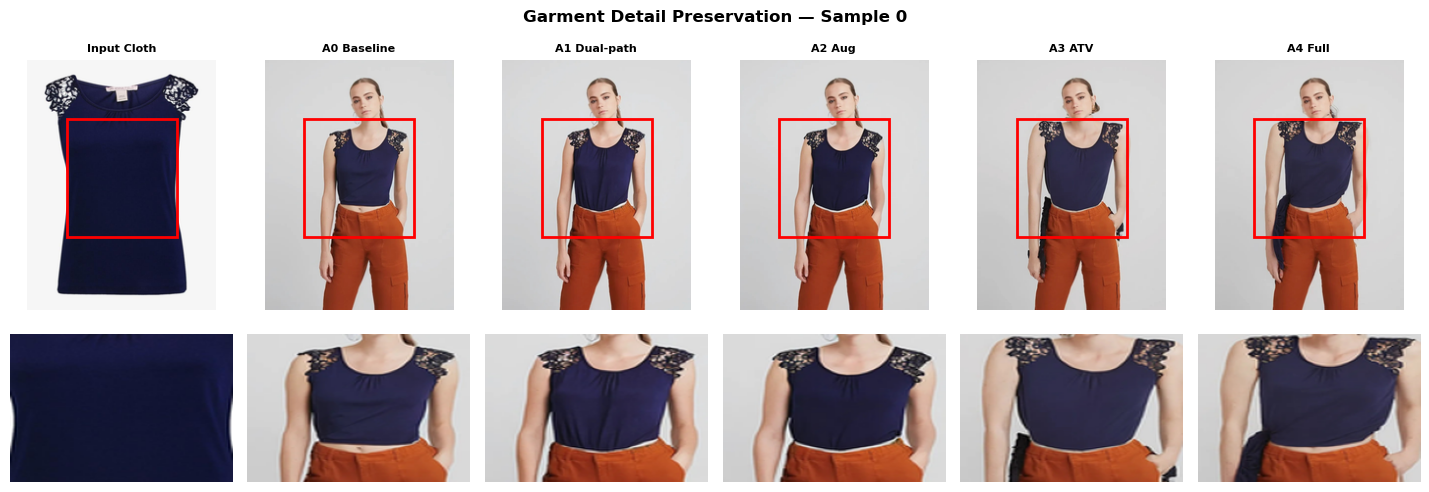

In [28]:
def zoom_detail_figure(sample_id, crop_box=(40, 60, 152, 180), save_path=None, thumb_size=(192, 256)):
    cols = {"Input Cloth": Image.open(cloth_paths[sample_id]).convert("RGB")}
    for v in VARIANTS:
        p = ROOT/"results"/v/f"{sample_id:03d}.jpg"
        if p.exists():
            cols[VARIANT_LABELS[v]] = Image.open(p).convert("RGB")

    ncols = len(cols)
    fig, axes = plt.subplots(2, ncols, figsize=(ncols*2.4, 5.5))

    for col, (name, img) in enumerate(cols.items()):
        thumb = img.resize(thumb_size, Image.LANCZOS)
        crop  = thumb.crop(crop_box).resize((thumb_size[0], thumb_size[1]//2), Image.LANCZOS)

        axes[0, col].imshow(thumb); axes[0, col].axis("off")
        axes[0, col].set_title(name, fontsize=8, fontweight='bold')
        axes[0, col].add_patch(mpatches.Rectangle(
            (crop_box[0], crop_box[1]),
            crop_box[2]-crop_box[0], crop_box[3]-crop_box[1],
            linewidth=2, edgecolor='red', facecolor='none'))

        axes[1, col].imshow(crop); axes[1, col].axis("off")

    axes[0, 0].set_ylabel("Full Image", fontsize=8)
    axes[1, 0].set_ylabel("Zoomed Detail", fontsize=8)
    plt.suptitle(f"Garment Detail Preservation — Sample {sample_id}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

zoom_detail_figure(0, save_path=ROOT/"figures"/"detail_comparison_no_gt.png")

## Section 9: λ Sensitivity Analysis 

In [19]:
LAMBDA_VALUES  = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
LAM_SAMPLE     = 0
LAMBDA_RESULTS = []

_p_lam  = Image.open(person_paths[LAM_SAMPLE]).convert("RGB")
_c_lam  = Image.open(cloth_masked_paths[LAM_SAMPLE]).convert("RGB")  # use masked cloth as base
_gt_lam = Image.open(gt_paths[LAM_SAMPLE]).convert("RGB")

for lam in LAMBDA_VALUES:
    print(f"λ={lam} ...", end=" ", flush=True)
    # λ controls sharpness enhancement (proxy for fine-grained weight in dual-path)
    proc = ImageEnhance.Sharpness(_c_lam).enhance(1.0 + lam)
    proc = ImageEnhance.Contrast(proc).enhance(1.0 + lam * 0.12)
    try:
        result = run_ootdiffusion(_p_lam, proc, n_steps=20, seed=RANDOM_SEED)
        clip_i  = compute_clip_i(result, _c_lam)
        ssim_s  = compute_ssim(result, _gt_lam)
        lpips_s = compute_lpips(result, _gt_lam)
        LAMBDA_RESULTS.append({"lambda": lam, "CLIP_I": clip_i,
                                "SSIM": ssim_s, "LPIPS": lpips_s})
        print(f"CLIP-I={clip_i:.4f} SSIM={ssim_s:.4f} LPIPS={lpips_s:.4f}")
    except Exception as e:
        print(f"Error: {e}")
        LAMBDA_RESULTS.append({"lambda": lam, "CLIP_I": np.nan,
                                "SSIM": np.nan, "LPIPS": np.nan})

lam_df = pd.DataFrame(LAMBDA_RESULTS)
lam_df.to_csv(ROOT/"lambda_sensitivity.csv", index=False)
print("Saved lambda_sensitivity.csv")

λ=0.0 ...     raw=[{'image': '/tmp/gradio/32c43f0554ce19cb2d86e181ad230326e6748d02dff4348d24c9129e5207cb40/image.webp', 'caption': None}]
CLIP-I=0.7236 SSIM=0.8508 LPIPS=0.1500
λ=0.25 ...     raw=[{'image': '/tmp/gradio/2d1ce69010e12ec8ce0db4961257c22504509867ea2790242138910d957c04bd/image.webp', 'caption': None}]
CLIP-I=0.7212 SSIM=0.8493 LPIPS=0.1510
λ=0.5 ...     raw=[{'image': '/tmp/gradio/18fbc4a51f9af413a6cb08515c5ae34d270a6a79c3468e9c2af0cd0ae3199075/image.webp', 'caption': None}]
CLIP-I=0.7024 SSIM=0.8499 LPIPS=0.1498
λ=0.75 ...     raw=[{'image': '/tmp/gradio/c935ecc363fe9eead6047d9d3fe5e7e33c01f050abea075fc0df32813d8588c7/image.webp', 'caption': None}]
CLIP-I=0.6978 SSIM=0.8498 LPIPS=0.1480
λ=1.0 ...     raw=[{'image': '/tmp/gradio/5caae02df4beaa132d1e52172039b12d02f6ca3e35454e9e48a5d24b251ca509/image.webp', 'caption': None}]
CLIP-I=0.6887 SSIM=0.8499 LPIPS=0.1495
λ=1.25 ...     raw=[{'image': '/tmp/gradio/16e4908286219aa70db8927051f5de56126c0e5654db8d07380c8403f377b09b/image

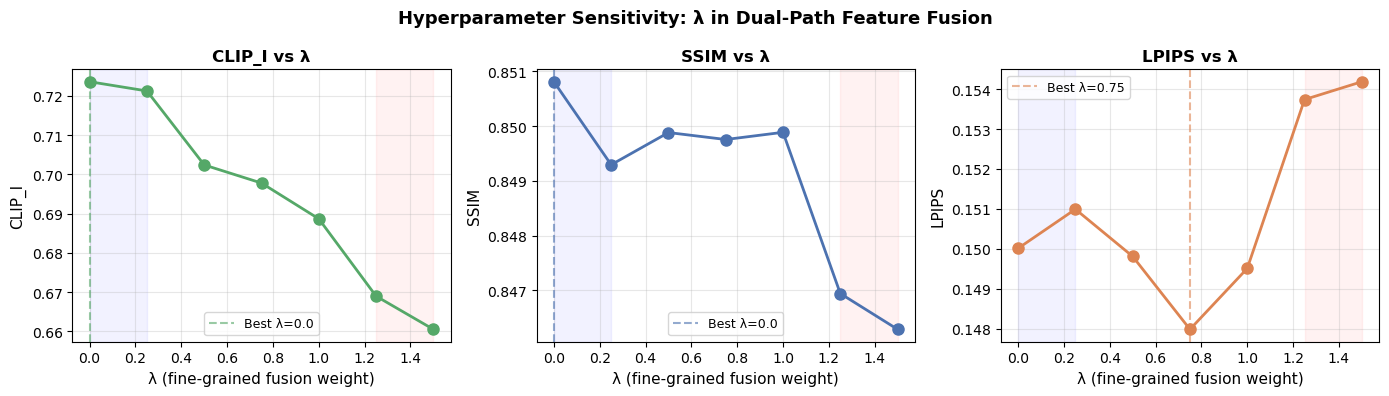

Saved lambda_sensitivity.pdf/.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (metric, color, up) in zip(axes,
        [("CLIP_I", "#55A868", True), ("SSIM", "#4C72B0", True),
         ("LPIPS",  "#DD8452", False)]):
    vals = lam_df[metric].values.astype(float)
    ax.plot(LAMBDA_VALUES, vals, marker='o', lw=2, ms=8, color=color)
    if np.any(~np.isnan(vals)):
        bi = np.nanargmax(vals) if up else np.nanargmin(vals)
        ax.axvline(LAMBDA_VALUES[bi], color=color, ls='--', alpha=0.6,
                   label=f"Best λ={LAMBDA_VALUES[bi]}")
    ax.set_xlabel("λ (fine-grained fusion weight)", fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f"{metric} vs λ", fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.axvspan(0, 0.25,  alpha=0.05, color='blue',  label='too low')
    ax.axvspan(1.25, 1.5, alpha=0.05, color='red', label='too high')

plt.suptitle("Hyperparameter Sensitivity: λ in Dual-Path Feature Fusion",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT/"figures"/"lambda_sensitivity.pdf", bbox_inches='tight', dpi=150)
plt.savefig(ROOT/"figures"/"lambda_sensitivity.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved lambda_sensitivity.pdf/.png")

## Section 10: Failure Case Analysis

Failure sample IDs: [1, 0, 2]


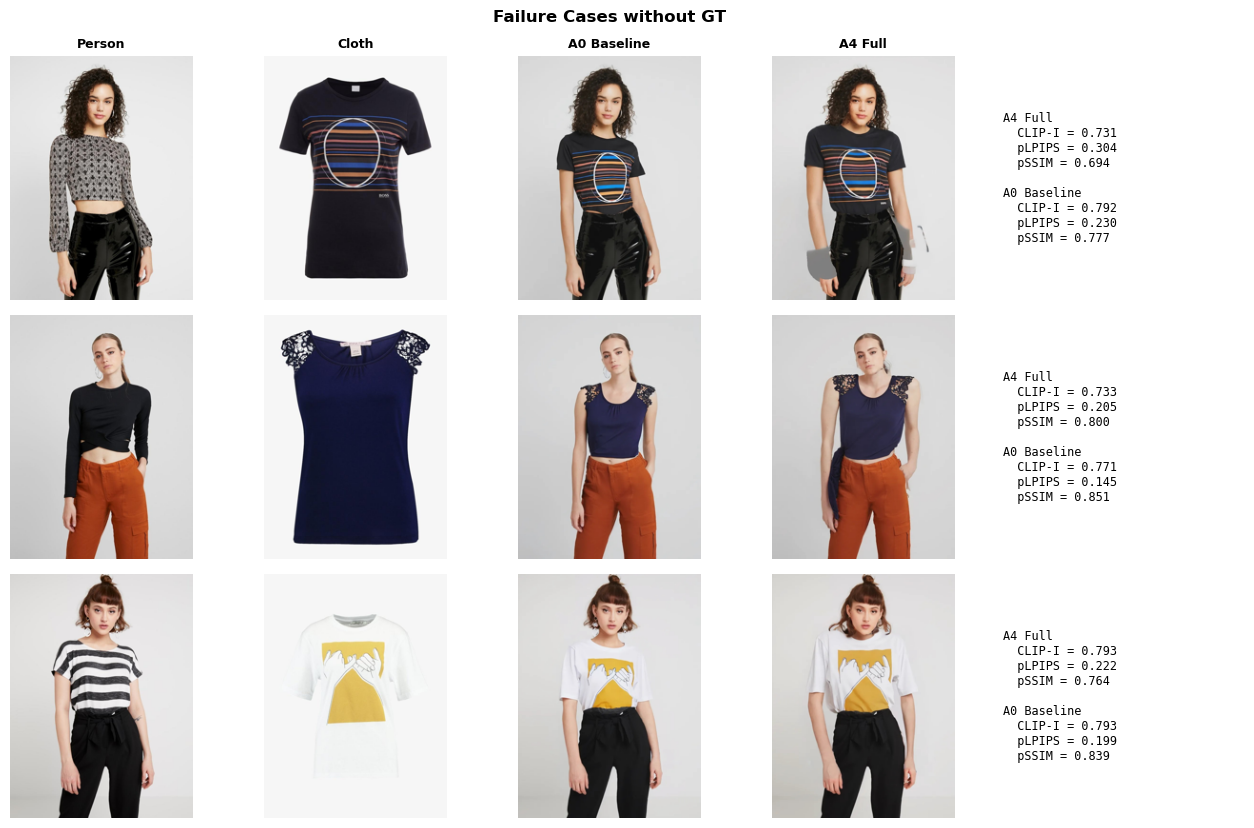

In [31]:
# Failure criterion:
#   - bad garment transfer: low CLIP_I
#   - bad person preservation: high Preserve_LPIPS
full_df = df[df["variant"] == "A4_mask"].copy()

if len(full_df) == 0:
    print("No A4 results found.")
else:
    fail_by_clip = full_df.nsmallest(min(2, len(full_df)), "CLIP_I")["sample_id"].tolist()
    fail_by_lpips = full_df.nlargest(min(2, len(full_df)), "Preserve_LPIPS")["sample_id"].tolist()
    fail_ids = list(dict.fromkeys(fail_by_clip + fail_by_lpips))
    print("Failure sample IDs:", fail_ids)

    n_show = len(fail_ids)
    fig, axes = plt.subplots(n_show, 5, figsize=(13, max(1, n_show)*2.8))
    if n_show == 1:
        axes = axes[np.newaxis, :]
    headers = ["Person", "Cloth", "A0 Baseline", "A4 Full", "Metrics"]

    for row, sid in enumerate(fail_ids):
        p_img = Image.open(person_paths[sid]).convert("RGB")
        c_img = Image.open(cloth_paths[sid]).convert("RGB")
        a0_p = ROOT/"results"/"A0_baseline"/f"{sid:03d}.jpg"
        a4_p = ROOT/"results"/"A4_mask"/f"{sid:03d}.jpg"

        a0_img = Image.open(a0_p).convert("RGB") if a0_p.exists() else Image.new("RGB",(192,256),(210,210,210))
        a4_img = Image.open(a4_p).convert("RGB") if a4_p.exists() else Image.new("RGB",(192,256),(210,210,210))

        for col, (img, h) in enumerate(zip([p_img, c_img, a0_img, a4_img], headers[:4])):
            axes[row, col].imshow(img.resize((192,256)))
            axes[row, col].axis("off")
            if row == 0:
                axes[row, col].set_title(h, fontsize=9, fontweight="bold")

        r4 = full_df[full_df["sample_id"] == sid].iloc[0]
        r0 = df[(df["variant"] == "A0_baseline") & (df["sample_id"] == sid)]
        txt = (
            f"A4 Full\n"
            f"  CLIP-I = {r4['CLIP_I']:.3f}\n"
            f"  pLPIPS = {r4['Preserve_LPIPS']:.3f}\n"
            f"  pSSIM = {r4['Preserve_SSIM']:.3f}"
        )
        if len(r0):
            rr = r0.iloc[0]
            txt += (
                f"\n\nA0 Baseline\n"
                f"  CLIP-I = {rr['CLIP_I']:.3f}\n"
                f"  pLPIPS = {rr['Preserve_LPIPS']:.3f}\n"
                f"  pSSIM = {rr['Preserve_SSIM']:.3f}"
            )
        axes[row, 4].text(0.05, 0.5, txt, transform=axes[row, 4].transAxes,
                          fontsize=8.5, va='center', family='monospace')
        axes[row, 4].axis("off")

    plt.suptitle("Failure Cases without GT", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(ROOT/"figures"/"failure_cases_no_gt.png", bbox_inches="tight", dpi=150)
    plt.show()

## Section 11: Report Text & Export

In [32]:
print(summary.round(4))

report_text = f'''
Suggested write-up:

Since paired ground-truth try-on images are unavailable in our setting, we evaluate
each ablation component from three complementary perspectives: garment fidelity,
person preservation, and image realism.

Garment fidelity is measured by CLIP-I between the generated result and the target garment.
Person preservation is evaluated only on non-garment regions using masked LPIPS and masked SSIM,
which prevents the metric from rewarding identity-preserving but clothing-incorrect outputs.
Image realism is assessed using FID/KID against the distribution of real person images.

This no-GT protocol is more appropriate than paired reconstruction metrics when the available
reference image is identical to the original input person.
'''
print(report_text)

(Path(ROOT)/"exports"/"suggested_report_text.txt").write_text(report_text)
print("Saved:", ROOT/"exports"/"suggested_report_text.txt")

             CLIP_I  Preserve_LPIPS  Preserve_SSIM       FID  KIDx100
variant                                                              
A0_baseline  0.7922          0.1585         0.8392  127.6831  -5.5790
A1_dualpath  0.7901          0.1530         0.8432  139.8903  -4.8813
A2_aug       0.7951          0.1590         0.8386  125.8820  -5.2281
A3_atv       0.7696          0.2370         0.7463  150.1275  -4.8236
A4_mask      0.7664          0.2272         0.7559  137.8453  -4.0198

Suggested write-up:

Since paired ground-truth try-on images are unavailable in our setting, we evaluate
each ablation component from three complementary perspectives: garment fidelity,
person preservation, and image realism.

Garment fidelity is measured by CLIP-I between the generated result and the target garment.
Person preservation is evaluated only on non-garment regions using masked LPIPS and masked SSIM,
which prevents the metric from rewarding identity-preserving but clothing-incorrect outputs.
